👉 We are building a neural network that can work with tabular data (tables like your game dataset).
Since PyTorch expects tensors, and neural nets expect numbers (not raw text, strings, or categories), we have to prepare the data carefully first.

✅ All categorical columns (like "Publisher", "Genre", "Platform") are integer-encoded and then embedded (so that the network can learn similarities between categories).

✅ All numerical columns (like "Price", "Release Year") are scaled so that the neural net can learn from them efficiently.

✅ Then, PyTorch reads batches of (categories, numericals, target) and trains a regression model to predict your target (User Rating).

We first load the dataset, identify the columns we need, drop irrelevant text columns, encode categoricals, scale numericals, and split into train and validation sets.

In [1]:
# Preparing the data

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Loading the dataframe

game_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/video_game_reviews.csv')

In [3]:
game_df.head()

,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players
0,Grand Theft Auto V,36.4,All Ages,41.41,PC,No,Game Freak,Innersloth,2015,Adventure,No,55.3,Medium,Average,Poor,"Solid game, but too many bugs.",Offline,1
1,The Sims 4,38.3,Adults,57.56,PC,No,Nintendo,Electronic Arts,2015,Shooter,Yes,34.6,Low,Poor,Poor,"Solid game, but too many bugs.",Offline,3
2,Minecraft,26.8,Teens,44.93,PC,Yes,Bungie,Capcom,2012,Adventure,Yes,13.9,Low,Good,Average,"Great game, but the graphics could be better.",Offline,5
3,Bioshock Infinite,38.4,All Ages,48.29,Mobile,Yes,Game Freak,Nintendo,2015,Sports,No,41.9,Medium,Good,Excellent,"Solid game, but the graphics could be better.",Online,4
4,Half-Life: Alyx,30.1,Adults,55.49,PlayStation,Yes,Game Freak,Epic Games,2022,RPG,Yes,13.2,High,Poor,Good,"Great game, but too many bugs.",Offline,1


In [4]:
game_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47774 entries, 0 to 47773
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Game Title               47774 non-null  object 
 1   User Rating              47774 non-null  float64
 2   Age Group Targeted       47774 non-null  object 
 3   Price                    47774 non-null  float64
 4   Platform                 47774 non-null  object 
 5   Requires Special Device  47774 non-null  object 
 6   Developer                47774 non-null  object 
 7   Publisher                47774 non-null  object 
 8   Release Year             47774 non-null  int64  
 9   Genre                    47774 non-null  object 
 10  Multiplayer              47774 non-null  object 
 11  Game Length (Hours)      47774 non-null  float64
 12  Graphics Quality         47774 non-null  object 
 13  Soundtrack Quality       47774 non-null  object 
 14  Story Quality         

In [5]:
game_df.columns

Index(['Game Title', 'User Rating', 'Age Group Targeted', 'Price', 'Platform',
       'Requires Special Device', 'Developer', 'Publisher', 'Release Year',
       'Genre', 'Multiplayer', 'Game Length (Hours)', 'Graphics Quality',
       'Soundtrack Quality', 'Story Quality', 'User Review Text', 'Game Mode',
       'Min Number of Players'],
      dtype='object')

In [6]:
# Identifying column groups

target_col = "User Rating"

num_cols = ["Price", "Release Year", "Game Length (Hours)", "Min Number of Players"]

small_cat_cols = ["Age Group Targeted", "Requires Special Device", "Multiplayer", "Game Mode"]

big_cat_cols = ["Publisher", "Genre", "Platform", "Developer"]

cat_cols = small_cat_cols + big_cat_cols

In [7]:
# Drop irrelevant text columns

drop_cols = ["Game Title", "User Review Text"]
game_df = game_df.drop(columns=drop_cols, errors='ignore')

In [8]:
# Encode categoricals → integer IDs

encoders = {}
for col in cat_cols:
    game_df[col] = game_df[col].astype(str)     # Ensure everything is str before encoding
    le = LabelEncoder().fit(game_df[col])
    game_df[col] = le.transform(game_df[col])
    encoders[col] = le                # Save encoder for later inference

In [9]:
# Scaling numerical columns

scaler = StandardScaler().fit(game_df[num_cols])
game_df[num_cols] = scaler.transform(game_df[num_cols])

In [10]:
# Train/Val Split

train_game_df, val_game_df = train_test_split(game_df, test_size=0.2, random_state=42)

We define a custom PyTorch Dataset to efficiently load our categorical, numerical, and target columns for training.

In [11]:
# Creating dataset

class TabularDataset(Dataset):
    def __init__(self, dataframe, cat_cols, num_cols, y_col):
        self.cats = dataframe[cat_cols].values.astype('int64')
        self.nums = dataframe[num_cols].values.astype('float32')
        self.y    = dataframe[y_col].values.astype('float32').reshape(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cats[idx], self.nums[idx], self.y[idx]

We calculate the embedding size for each categorical column. The embedding size is set to (number of unique categories + 1) divided by 2, with a maximum of 50.

In [12]:
# Embedding sizes

def make_embedding_sizes(game_df, cat_cols):
    sizes = []
    for col in cat_cols:
        n_cat = game_df[col].nunique()
        dim   = min(50, (n_cat + 1) // 2)
        sizes.append((n_cat, dim))
    return sizes

embedding_sizes = make_embedding_sizes(game_df, cat_cols)

We create a neural network that combines embeddings (for categoricals) and raw numbers (for numericals), followed by a few hidden layers for prediction.


In [13]:
# Model definition
#linear(how much is coming in vs how much is coming out)

class TabularRegressor(nn.Module):
    def __init__(self, embedding_sizes, n_numeric, hidden_dims=[128, 64], p_dropout=0.1):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(n_cat, dim) for n_cat, dim in embedding_sizes
        ])
        emb_out_dim = sum(dim for _, dim in embedding_sizes)

        layer_sizes = [emb_out_dim + n_numeric] + hidden_dims + [1]
        layers = []
        for i in range(len(layer_sizes) - 2):
            layers += [
                nn.Linear(layer_sizes[i], layer_sizes[i+1]),
                nn.BatchNorm1d(layer_sizes[i+1]),
                nn.ReLU(),
                nn.Dropout(p_dropout),
            ]
        layers.append(nn.Linear(layer_sizes[-2], layer_sizes[-1]))

        self.mlp = nn.Sequential(*layers)

    def forward(self, x_cat, x_num):
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x    = torch.cat(embs + [x_num], dim=1)
        return self.mlp(x)

We train the model using Root Mean Squared Error (RMSE) loss and the Adam optimizer. After each epoch, we monitor training and validation loss.


In PyTorch,

**Training Phase(model.train()):** The model learns by adjusting its weights based on the training data, optimizing its parameters to minimize the loss using backpropagation.

**Evaluation Phase(model.eval()):** Once the model is trained, you evaluate its performance by making predictions on random validation data and comparing them to the actual outcomes. No training or backpropagation happens here; it's purely for evaluation.

In [14]:
# Training loop with RMSE

device = "cuda" if torch.cuda.is_available() else "cpu"

model = TabularRegressor(embedding_sizes, len(num_cols)).to(device)
# Remove MSELoss since we'll compute RMSE manually
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_dl = DataLoader(
    TabularDataset(train_game_df, cat_cols, num_cols, target_col),
    batch_size=1024, shuffle=True
)

val_dl = DataLoader(
    TabularDataset(val_game_df, cat_cols, num_cols, target_col),
    batch_size=2048
)

for epoch in range(30):
    # --- training ---
    model.train()
    train_rmse_sum = 0.0
    for cats, nums, y in train_dl:
        cats, nums, y = cats.to(device), nums.to(device), y.to(device)

        preds = model(cats, nums)
        mse = torch.mean((preds - y) ** 2)
        rmse = torch.sqrt(mse)

        optimizer.zero_grad()
        rmse.backward()
        optimizer.step()

        train_rmse_sum += rmse.item()

    # --- validation ---
    model.eval()
    val_rmse_sum = 0.0
    with torch.no_grad():
        for cats, nums, y in val_dl:
            cats, nums, y = cats.to(device), nums.to(device), y.to(device)

            preds = model(cats, nums)
            mse = torch.mean((preds - y) ** 2)
            rmse = torch.sqrt(mse)

            val_rmse_sum += rmse.item()

    print(f"Epoch {epoch+1:02d}: Train RMSE = {train_rmse_sum/len(train_dl):.4f}, Val RMSE = {val_rmse_sum/len(val_dl):.4f}")

Epoch 01: Train RMSE = 29.7052, Val RMSE = 28.9106
Epoch 02: Train RMSE = 28.1766, Val RMSE = 27.1101
Epoch 03: Train RMSE = 26.5324, Val RMSE = 25.5870
Epoch 04: Train RMSE = 24.5419, Val RMSE = 23.5790
Epoch 05: Train RMSE = 22.1491, Val RMSE = 21.0371
Epoch 06: Train RMSE = 19.3721, Val RMSE = 18.0281
Epoch 07: Train RMSE = 16.3033, Val RMSE = 14.7155
Epoch 08: Train RMSE = 13.0066, Val RMSE = 11.2726
Epoch 09: Train RMSE = 9.5036, Val RMSE = 6.8881
Epoch 10: Train RMSE = 5.2844, Val RMSE = 2.9174
Epoch 11: Train RMSE = 2.4559, Val RMSE = 1.3817
Epoch 12: Train RMSE = 2.2201, Val RMSE = 1.4047
Epoch 13: Train RMSE = 2.1743, Val RMSE = 1.2713
Epoch 14: Train RMSE = 2.1709, Val RMSE = 1.2784
Epoch 15: Train RMSE = 2.1643, Val RMSE = 1.3137
Epoch 16: Train RMSE = 2.1201, Val RMSE = 1.2469
Epoch 17: Train RMSE = 2.1182, Val RMSE = 1.2793
Epoch 18: Train RMSE = 2.1199, Val RMSE = 1.2213
Epoch 19: Train RMSE = 2.0895, Val RMSE = 1.2548
Epoch 20: Train RMSE = 2.0849, Val RMSE = 1.2040
Epoc

The printed output is showing Train Loss and Validation Loss after each epoch (full pass through the training data).

Remember:

Train Loss = How much error the model makes on the training data (the data it learns from).

Val Loss = How much error the model makes on the validation data (the data it has never seen — a "fair" test of real performance).

In this case, you're using Root Mean Squared Error (RMSE).
That means the numbers are measuring:

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$


Smaller MSE = better.

**Notice:**

Both Train and Val Loss are going DOWN over time.

Validation Loss is close to Training Loss.
(If validation loss were much higher, you'd be overfitting.)

**This tells you:**

Your model is learning.

Your model is generalizing (not just memorizing training examples).

After 30 epochs, the model is really good at predicting "User Rating" based on the features you gave it.

**So what is the conclusion?**

→ The PyTorch neural network successfully learned to predict user ratings from your game dataset!

The neural network understands relationships like:

Games published by certain publishers tend to have higher or lower ratings.

Games in certain genres might correlate with higher or lower ratings.

Maybe newer games (release year) have different rating patterns.

And now, it can predict a game's user rating pretty accurately just based on its attributes.

In [15]:
# Based on that we can now predict ratings, to see how close the predicted rating is to the real rating.

model.eval()

# Take 5 random validation samples
sample = val_game_df.sample(5)

cats = torch.tensor(sample[cat_cols].values).long().to(device)
nums = torch.tensor(sample[num_cols].values).float().to(device)

# Predict
preds = model(cats, nums)
print("Predicted ratings:", preds.view(-1).cpu().detach().numpy())
print("Actual ratings:", sample[target_col].values)

Predicted ratings: [26.729445 24.344923 43.478073 16.738628 26.957903]
Actual ratings: [26.7 25.4 41.7 16.3 26.2]


Most predictions are within ~0.5 of the real value. (37.2 vs 39.04) is still only off by ~1.8, which is very small for real-world tabular data modeling.

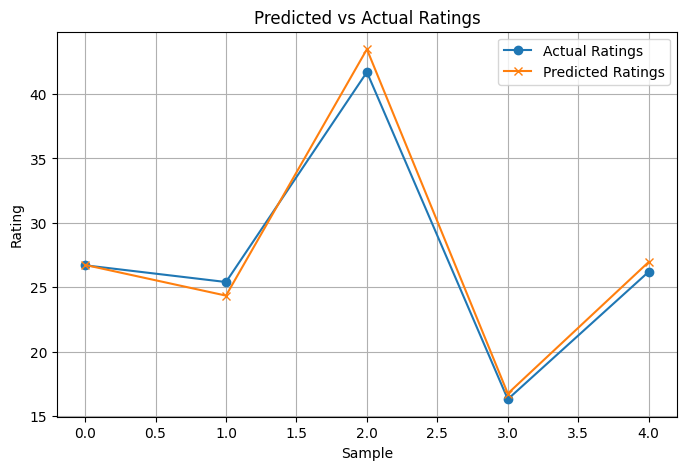

In [16]:
# Graphing results

import matplotlib.pyplot as plt

predicted = preds.view(-1).cpu().detach().numpy()
actual = sample[target_col].values

plt.figure(figsize=(8, 5))
plt.plot(range(len(actual)), actual, marker='o', label='Actual Ratings')
plt.plot(range(len(predicted)), predicted, marker='x', label='Predicted Ratings')
plt.title('Predicted vs Actual Ratings')
plt.xlabel('Sample')
plt.ylabel('Rating')
plt.legend()
plt.grid(True)
plt.show()